## Part 2: Solving a non-linear initial-value problem with the implicit Euler scheme

A municipality plans to build a large battery energy storage facility and is looking for a suitable location. The potential location is close (1 km) to a well that is used to abstract drinking water from an aquifer with a constant pumping rate $Q$. In the event of a fire or accident in the battery energy storage facility, contaminants could infiltrate into the subsurface.
Therefore, the municipality wants to assess the risk of contamination in case a leakage occurs.
One requirement is that the facility cannot be built in the groundwater protection zone, which is delineated by the area in which a water parcel takes less than 25 years to reach the well.

![](https://github.com/TUDelft-MUDE/source-files/raw/main/file/WS1.3/particle_tracking_schematic.svg)

Assuming radial flow towards the well in a uniform aquifer, the distance $r$ of a groundwater particle from the well is governed by

$$\frac{dr}{dt} = - \frac{Q}{2\pi r n b} = -\alpha\frac{1}{r}\,,$$

where $n$ is porosity, $b$ is the aquifer thickness, and $\alpha = \frac{Q}{2\pi nb}$.

To find out how long it takes for a particle starting at a distance $r_0$ to reach the well, you need to solve the ODE until the distance $r$ equals the well radius, $r_{\mathrm{well}}$.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
Q = 3000 # m³/d
b = 20 # m
n = 0.3

alpha = Q / (2 * np.pi * b * n)


r0 = 1000 # m
r_well = 0.2 # m


> **Task 2.1**:
> 
> Formulate the implicit Euler scheme for the ODE.



For general nonlinear ODEs, the implicit Euler update cannot usually be solved directly. Instead, we use an iterative scheme – Newton-Raphson – to solve for $r_{i+1}$.[<sup>1</sup>](#fn1)

In the Newton-Raphson scheme, the expression for the new value, $r_{i+1}^{j+1}$, is given by:

$$r_{i+1}^{j+1} = r_{i+1}^{j} - \frac{q(r_{i+1}^{j})}{q^\prime(r_{i+1}^{j})}$$

Here $q$ is obtained by rearranging the implicit Euler expression so that one side of the equation is zero.

<sup id="fn1">1</sup> Note that the equation in this specific example is quadratic, and thus, could be solved directly, even though it is non-linear. For the sake of practicing, we ask you to use the Newton-Raphson method nevertheless.</span>




> **Task 2.2**:
> 
> Formulate an expression for $q$ by rearranging the equation for the implicit Euler scheme from task 2.1.


> **Task 2.3**:
> 
> Complete the code cell below to implement an implicit Euler scheme with Newton Raphson iterations for the particle-tracking ODE.

In [16]:
# Solve the IVP with an implicit Euler scheme, using the Newton-Raphson method

# Initialize variables
r_next = r0
r_previous = r0
t_previous = 0
dt = 50 # days

times = [t_previous]
r = [r0]

# Set parameters for the Newton-Raphson method and time iteration
tolerance = 1e-6
max_times = 1e4
max_iter = 50

# Loop over time
for iteration in range(int(max_times)):
    t_next = t_previous+dt  ### YOUR CODE HERE ###
    times.append(t_next)
    iter_count = 0
    # Loop for Newton-Raphson iterations
    while iter_count < max_iter:
        # Define the function and its derivative
        q = r_next-r_previous+dt*alpha/r_next### YOUR CODE HERE ###
        q_prime = 1-dt*alpha/(r_next)**2### YOUR CODE HERE ###

        # Update the guess using Newton-Raphson formula
        r_update = r_next-q/q_prime### YOUR CODE HERE ###

        # Check for convergence
        if abs(r_update - r_next) < tolerance:
            break

           
        iter_count += 1

    # Update the values for the next time step
    r_previous = r_next #καταχωρεί την πλέον προηγούμενη τιμή ως επόμενη αρχική
    r_next = r_update #καταχωρεί την καινούρια σωστή νεά τιμή
    r.append(r_next)
    t_previous = t_next

    # Stop the simulation when the particle reaches the well (r <= 0.2 m)
    if r_next <= r_well:
        break


# Note/Question:
While the above code seems to be working and the graph seems to converge with the analytical, the following thoughts have occured to me:
1. As the Newton-Raphson loop is constructed, it looks like in every iteration, the same `r_next` is used, which results in the same `r_update`, meaning even if there is no converge and the tolerance is not fulfilled, after `max_iter` steps, the loop stops and the same initial `r_next` and `r_update` values that were calculated from the first step are used.
2. On the next step of the Euler implicit loop, if `r_previous=r_next` and then `r_next=r_update` are defined, then in the next step, `r_previous`=r(i) <sup>0</sup> instead pf r(i)<sup>j</sup>=*correct r(i)value*. 
3. In the N-R method, the first estimate for the next value, r<sub>i+1</sub><sup>0</sup> is equal to the previous value r<sub>i</sub> <sup>j</sup>?

> **Task 2.4**:
> 
> Run the code cell below to plot the numerical solution against the analytical solution

(0.0, 1000.0)

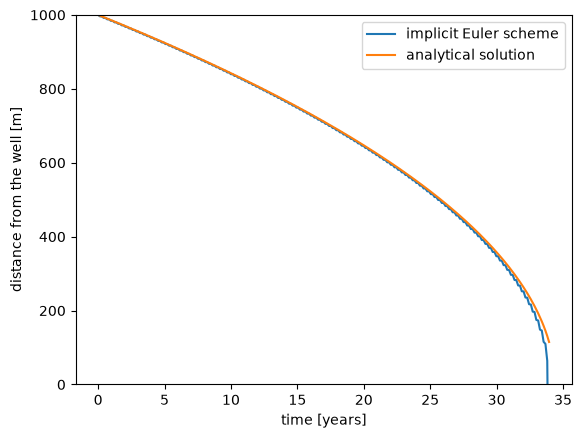

In [17]:
years = np.array(times) / 365.25
plt.plot(years, r, label="implicit Euler scheme")
plt.xlabel("time [years]")
plt.ylabel("distance from the well [m]")
r_analytical = np.sqrt(-alpha * np.array(times) + r0**2)
plt.plot(years, r_analytical, label="analytical solution")
plt.legend()
plt.ylim(bottom=0, top =r0)

> **Task 2.5**:
> 
> Run the code cell below to compare the time it takes until the particle reaches the well between the numerical and analytical solution.

In [18]:
t_end_analytical = (r0**2 - r_well**2) / alpha
t_end_numerical = times[-1]

print("Time needed to reach the well (r=r_well):\n")
print(f"Analytical solution:\t{t_end_analytical / 365.25:.2f} years")
print(f"Numerical solution:\t{t_end_numerical / 365.25:.2f} years")

Time needed to reach the well (r=r_well):

Analytical solution:	34.40 years
Numerical solution:	33.95 years


> **Task 2.6**:
> 
> Based on this estimate, would you recommend approving the proposed location? Explain your reasoning.

***my answer:***
 
it would take more than 25 years to reach the well, thus it is considered an ideal location. Based on the numerical solution, it could be as close as almost 500m (?)

> By Ronald Brinkgreve, Anna Störiko, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).